### Step 1: Load and Explore the Dataset
- First, we'll load the dataset from the provided URL and perform initial exploration.

In [ ]:
# Import necessary libraries
import pandas as pd

# Load the dataset
url = "https://raw.githubusercontent.com/syedanwarafridi/Social-Media-and-Mental-Health/refs/heads/main/smmh.csv"
df = pd.read_csv(url)

# Display the first few rows
df.head()


,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


###Step 2: Data Preprocessing
- We'll clean the data, handle missing values, and encode categorical variables.

In [ ]:
# Drop rows with missing values
df.dropna(inplace=True)

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

# List of categorical columns to encode
categorical_cols = ['2. Gender', '3. Relationship Status', '4. Occupation Status',
                    '5. What type of organizations are you affiliated with?', '6. Do you use social media?']

# Initialize LabelEncoder
le = LabelEncoder()

# Encode each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Display the processed DataFrame
df.head()


,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,1,1,3,10,1,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,0,3,3,10,1,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,0,3,3,10,1,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,0,3,3,10,1,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,0,3,3,10,1,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


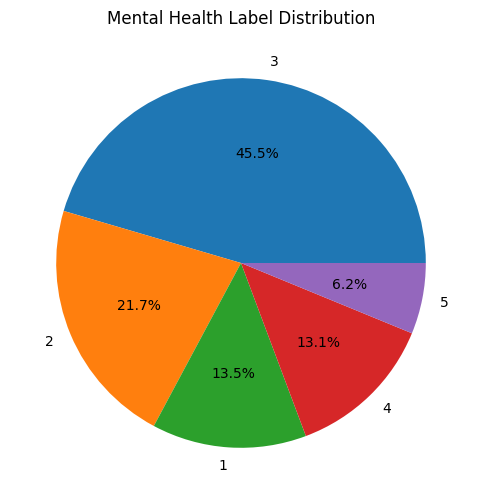

In [ ]:
# Show mental health label distribution
import matplotlib.pyplot as plt

label_counts = df[target].value_counts()

plt.figure(figsize=(6,6))
label_counts.plot.pie(autopct='%1.1f%%', labels=label_counts.index)
plt.title("Mental Health Label Distribution")
plt.ylabel("")
plt.show()


###Step 3: Feature Selection and Target Variable
- We'll select relevant features and define the target variable for our model.

In [ ]:
# Define features and target
features = ['2. Gender', '3. Relationship Status', '4. Occupation Status',
            '5. What type of organizations are you affiliated with?', '6. Do you use social media?',
            '9. How often do you find yourself using Social media without a specific purpose?',
            '10. How often do you get distracted by Social media when you are busy doing something?',
            '11. Do you feel restless if you haven\'t used Social media in a while?',
            '12. On a scale of 1 to 5, how easily distracted are you?',
            '13. On a scale of 1 to 5, how much are you bothered by worries?',
            '14. Do you find it difficult to concentrate on things?',
            '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
            '17. How often do you look to seek validation from features of social media?',
            '18. How often do you feel depressed or down?',
            '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?',
            '20. On a scale of 1 to 5, how often do you face issues regarding sleep?']

target = '16. Following the previous question, how do you feel about these comparisons, generally speaking?'

# Encode the target variable
df[target] = le.fit_transform(df[target])

# Define X and y
X = df[features]
y = df[target]


###Step 4: Train-Test Split
- We'll split the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


###Step 5: Build and Train the ANN Model
- We'll build a simple Artificial Neural Network using TensorFlow/Keras.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(y.unique()), activation='softmax'))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test))


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3973 - loss: 1.5452 - val_accuracy: 0.4505 - val_loss: 1.4072
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4392 - loss: 1.4025 - val_accuracy: 0.4176 - val_loss: 1.4590
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4715 - loss: 1.3686 - val_accuracy: 0.4725 - val_loss: 1.3958
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4700 - loss: 1.3478 - val_accuracy: 0.4286 - val_loss: 1.4115
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5141 - loss: 1.2561 - val_accuracy: 0.4066 - val_loss: 1.3980
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4927 - loss: 1.2896 - val_accuracy: 0.4505 - val_loss: 1.4641
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5038 - loss: 1.2398 - val_accuracy: 0.4505 - val_loss: 1.4319
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5040 - loss: 1.2360 - val_accuracy: 0.4176 - val_loss: 1.3706
Ep

In [ ]:
# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

# Print classification report
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.30      0.21        10
           1       0.30      0.12      0.17        26
           2       0.49      0.68      0.57        37
           3       0.22      0.18      0.20        11
           4       0.50      0.14      0.22         7

    accuracy                           0.37        91
   macro avg       0.33      0.28      0.27        91
weighted avg       0.37      0.37      0.34        91



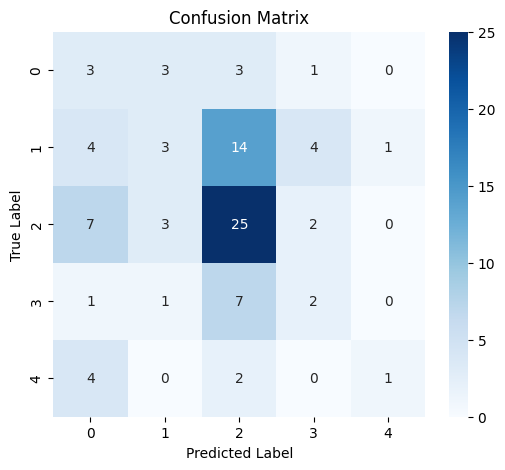

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


###Step 6: Evaluate the Model
- We'll evaluate the model's performance and visualize the results.

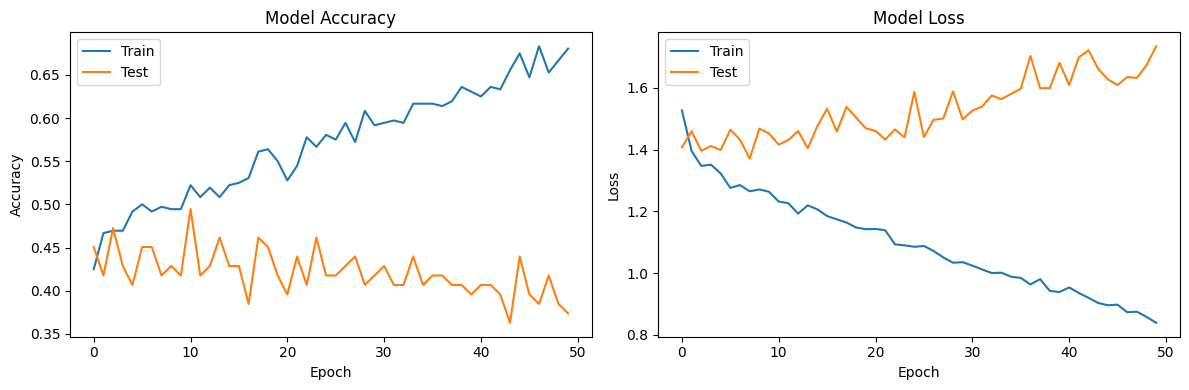

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


###Step 7: Implement a Simple BERT-Based Sentiment Classifier
- Use BERT embeddings combined with a lightweight neural network to classify text sentiment, demonstrating how to generate meaningful, human-readable outputs from BERT representations.

In [ ]:
from transformers import BertTokenizer, TFBertModel
import tensorflow as tf
import numpy as np

# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

# Example sentences (texts + labels)
texts = ["I feel happy today", "I'm feeling very low and depressed"]
labels = [1, 0]  # 1 = Positive, 0 = Negative

# Tokenize inputs
inputs = tokenizer(texts, return_tensors='tf', padding=True, truncation=True, max_length=64)

# Get BERT embeddings (use [CLS] token representation, index 0)
outputs = bert_model(inputs)
cls_embeddings = outputs.last_hidden_state[:, 0, :]  # shape: (batch_size, hidden_size)

# Define a simple classifier on top of BERT CLS embeddings
classifier = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid')  # output: probability between 0 and 1
])

# Compile the classifier
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train classifier on these two samples (just for demo, usually need more data)
classifier.fit(cls_embeddings, np.array(labels), epochs=10, verbose=0)

# Predict sentiment probabilities
pred_probs = classifier.predict(cls_embeddings)

# Print results nicely
for text, prob in zip(texts, pred_probs):
    sentiment = "Positive" if prob > 0.5 else "Negative"
    print(f"Text: '{text}' → Sentiment: {sentiment} ({prob[0]:.2f})")


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Text: 'I feel happy today' → Sentiment: Negative (0.44)
Text: 'I'm feeling very low and depressed' → Sentiment: Negative (0.31)
